In [1]:
# begin by importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('spx.csv')
df


,date,close
0,02-Jan-86,209.59
1,03-Jan-86,210.88
2,06-Jan-86,210.65
3,07-Jan-86,213.80
4,08-Jan-86,207.97
...,...,...
8187,25-Jun-18,2717.07
8188,26-Jun-18,2723.06
8189,27-Jun-18,2699.63
8190,28-Jun-18,2716.31


In [3]:
# we want to now simulate potential future paths for the stock
no_simulations = 10000
trading_days = 252

simulations = np.zeros((no_simulations, trading_days))
final_price = df['close'].iloc[-1]
daily_returns = df['close'].pct_change().dropna()


In [4]:
# loop through number of simulations to begin predicting future cumulative returns 
for i in range(no_simulations):
    daily_returns_sample = np.random.choice(daily_returns, size=trading_days, replace=True)
    cumulative_returns = np.cumprod(1 + daily_returns_sample)
    simulations[i, :] = final_price * cumulative_returns
print(simulations)


[[2664.00453177 2630.20650032 2619.55088774 ... 2038.0393529
  2035.14312947 2009.54877746]
 [2731.15395666 2699.61720975 2717.10613781 ... 3174.94937328
  3175.5647133  3180.35180434]
 [2719.96134898 2684.2068653  2691.23042319 ... 3282.76997721
  3252.1913831  3201.90520359]
 ...
 [2725.98252849 2727.14332602 2785.38178508 ... 2498.11278848
  2502.35637577 2549.78537017]
 [2727.81035632 2749.63732534 2728.36718623 ... 2490.97667457
  2478.67197571 2461.1305987 ]
 [2703.33974914 2727.05697082 2707.99603306 ... 2370.81802125
  2283.82063916 2284.30518111]]


In [5]:
print(simulations[2, 0:4])
# here we're showing the cumulative returns of 4 random trading days 

[2719.96134898 2684.2068653  2691.23042319 2699.66457462]


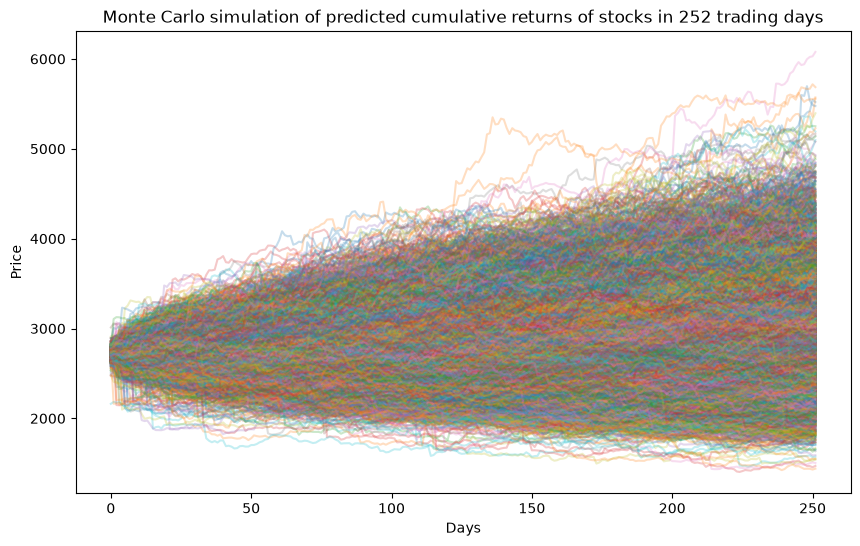

In [6]:
# using plt to plot our results of cumulative returns 
plt.figure(figsize=(10,6))
for i in range(no_simulations):
    plt.plot(simulations[i], alpha=0.25)
plt.title('Monte Carlo simulation of predicted cumulative returns of stocks in 252 trading days')
plt.xlabel('Days')
plt.ylabel('Price')
plt.show()